**MALAVIKA B S**

In [1]:
import pandas as pd
df = pd.read_csv("/content/AB_NYC_2019.csv.zip")

In [2]:
print(df.head())

     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1                  9  20

In [3]:
print(df.shape)

(48895, 16)


In [4]:
print(df.columns)

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')


In [5]:
print(df.dtypes)

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [10]:
print("Numerical Columns")
print(df.select_dtypes(include=['int64','float64']).columns)
print("Categorical Columns")
print(df.select_dtypes(include=['object']).columns)

Numerical Columns
Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')
Categorical Columns
Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'last_review'],
      dtype='object')


In [11]:
missing = df.isnull().sum()

percentage = (missing/len(df))*100

print(pd.DataFrame({
    "Missing Values":missing,
    "Percentage":percentage
}))

                                Missing Values  Percentage
id                                           0    0.000000
name                                        16    0.032723
host_id                                      0    0.000000
host_name                                   21    0.042949
neighbourhood_group                          0    0.000000
neighbourhood                                0    0.000000
latitude                                     0    0.000000
longitude                                    0    0.000000
room_type                                    0    0.000000
price                                        0    0.000000
minimum_nights                               0    0.000000
number_of_reviews                            0    0.000000
last_review                              10052   20.558339
reviews_per_month                        10052   20.558339
calculated_host_listings_count               0    0.000000
availability_365                             0    0.0000

In [12]:
df = df.drop("last_review", axis=1)

In [13]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

In [14]:
df = df.drop(["id","name","host_id","host_name"], axis=1)

print(df.head())

  neighbourhood_group neighbourhood  latitude  longitude        room_type  \
0            Brooklyn    Kensington  40.64749  -73.97237     Private room   
1           Manhattan       Midtown  40.75362  -73.98377  Entire home/apt   
2           Manhattan        Harlem  40.80902  -73.94190     Private room   
3            Brooklyn  Clinton Hill  40.68514  -73.95976  Entire home/apt   
4           Manhattan   East Harlem  40.79851  -73.94399  Entire home/apt   

   price  minimum_nights  number_of_reviews  reviews_per_month  \
0    149               1                  9               0.21   
1    225               1                 45               0.38   
2    150               3                  0               0.00   
3     89               1                270               4.64   
4     80              10                  9               0.10   

   calculated_host_listings_count  availability_365  
0                               6               365  
1                               

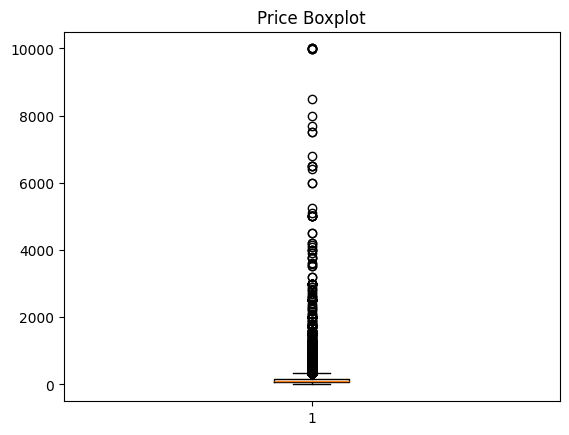

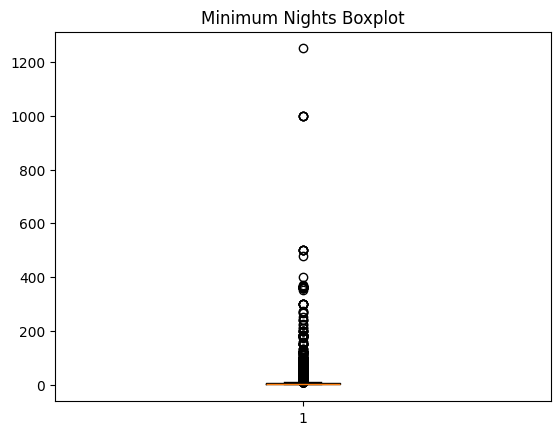

In [15]:
import matplotlib.pyplot as plt

plt.boxplot(df["price"])
plt.title("Price Boxplot")
plt.show()

plt.boxplot(df["minimum_nights"])
plt.title("Minimum Nights Boxplot")
plt.show()

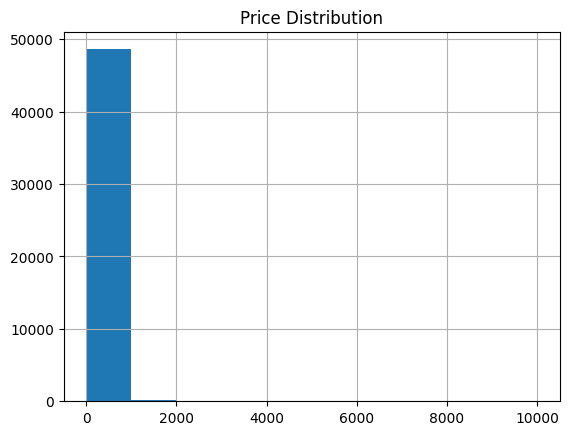

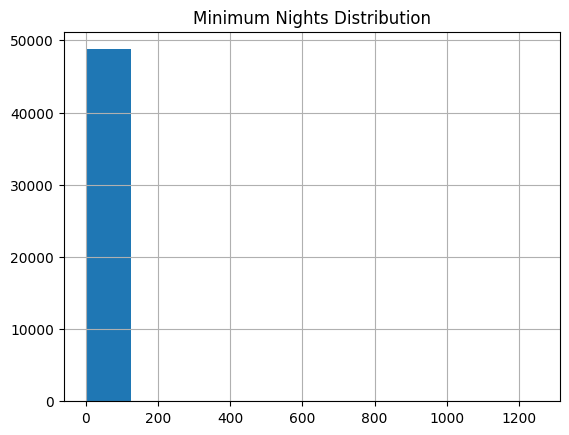

In [16]:
df["price"].hist()
plt.title("Price Distribution")
plt.show()

df["minimum_nights"].hist()
plt.title("Minimum Nights Distribution")
plt.show()

In [17]:
price_limit = df["price"].quantile(0.95)
df = df[df["price"] <= price_limit]
night_limit = df["minimum_nights"].quantile(0.95)
df = df[df["minimum_nights"] <= night_limit]

In [18]:
df = df.drop("neighbourhood", axis=1)

In [19]:
df = pd.get_dummies(df,
                    columns=["neighbourhood_group","room_type"],
                    drop_first=True)

print(df.head())

   latitude  longitude  price  minimum_nights  number_of_reviews  \
0  40.64749  -73.97237    149               1                  9   
1  40.75362  -73.98377    225               1                 45   
2  40.80902  -73.94190    150               3                  0   
3  40.68514  -73.95976     89               1                270   
4  40.79851  -73.94399     80              10                  9   

   reviews_per_month  calculated_host_listings_count  availability_365  \
0               0.21                               6               365   
1               0.38                               2               355   
2               0.00                               1               365   
3               4.64                               1               194   
4               0.10                               1                 0   

   neighbourhood_group_Brooklyn  neighbourhood_group_Manhattan  \
0                          True                          False   
1             

In [20]:
X = df.drop("price", axis=1)
y = df["price"]

In [21]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [22]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [23]:
y_pred = model.predict(X_test)

In [24]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

print("R2 Score:",r2_score(y_test,y_pred))

print("MAE:",mean_absolute_error(y_test,y_pred))

print("MSE:",mean_squared_error(y_test,y_pred))

print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

R2 Score: 0.47082773500021025
MAE: 38.5408749155387
MSE: 2834.959378892661
RMSE: 53.244336589844565


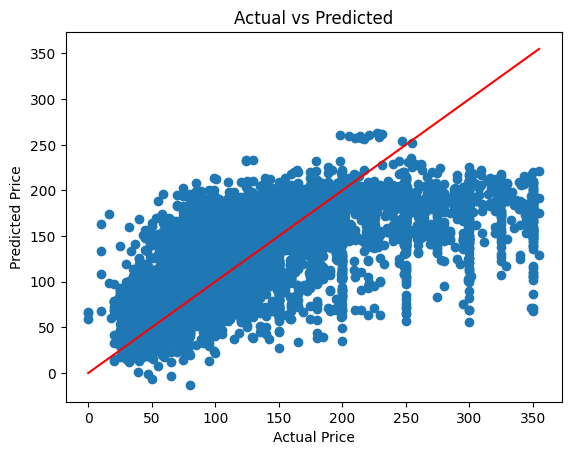

In [25]:
import matplotlib.pyplot as plt

plt.scatter(y_test,y_pred)

plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],
         color="red")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

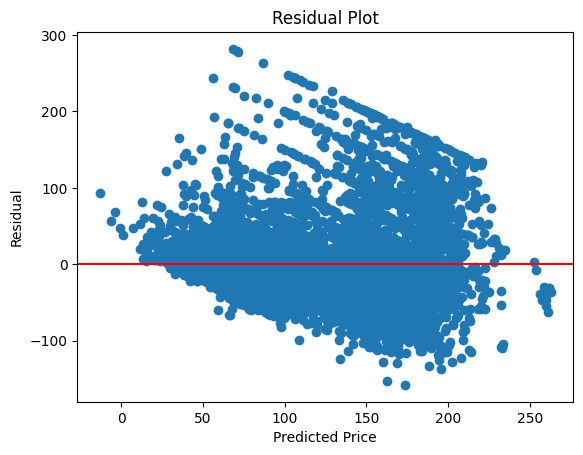

In [27]:
residual = y_test - y_pred
plt.scatter(y_pred,residual)
plt.axhline(y=0,color="red")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

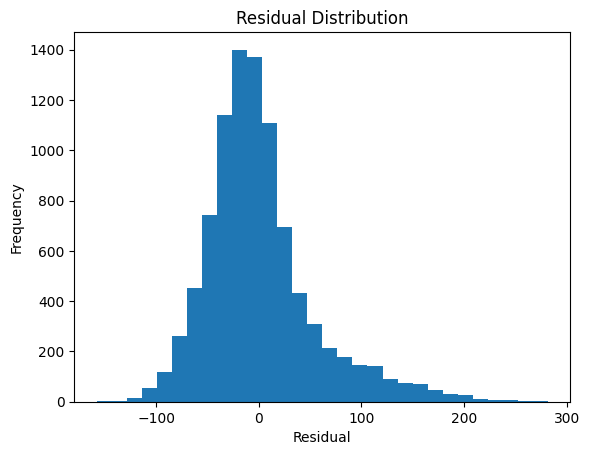

In [28]:
plt.hist(residual,bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

Task 7.3: Answer the final project question: Does the model perform
better on cheap listings or expensive listings, and why?

ANSWER : The model performs better on cheaper Airbnb listings than expensive listings.

Reason:
• Most listings in the dataset are low to medium priced.
• High-priced luxury listings are fewer and more difficult to predict.
• Therefore, prediction errors are usually larger for expensive listings.
